In [36]:
import pandas as pd 
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math
import warnings
warnings.filterwarnings("ignore")
from rdkit import Chem
from rdkit.Chem import Descriptors
from tqdm import tqdm
from mordred import Calculator, descriptors
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV)
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score,roc_curve, auc, f1_score,
                              matthews_corrcoef, confusion_matrix,
                              classification_report, precision_score,
                              recall_score, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

In [37]:
path ="C:/Users/angel/Desktop/Master/TFM/estructuras"
all_files = glob.glob(os.path.join(path, "*.csv"))

steps_log = []
df_list = []
li = []
for filename in all_files:
    df= pd.read_csv(filename, index_col=None, header=0, sep=';')
    li.append(df)
df_raw = pd.concat(li,axis=0, ignore_index=True)

df_raw.to_csv('dataset_unificado.csv', index=False, sep= ';')

Aplicacion del criterio de clasificacion donde aquellos compuestos que necesitan menos de 1 µM serán considerados activos mientras que aquellos compuestos que necesitan mas o 1 µM serán considerados inactivos. 

In [38]:
def get_full_cleaned_dataset(df_raw):
    df = df_raw.copy()
    df['Standard Value'] = pd.to_numeric(df['Standard Value'], errors='coerce')
    df = df.dropna(subset= ['Standard Value','Standard Units', 'Smiles'])

    def convert_to_um(row):
        val = row['Standard Value']
        unit = str(row['Standard Units']).lower()
        smiles = row['Smiles']
        if unit =='nm':
            return val / 1000
        if 'um' in unit or 'µm' in unit:
            return val
        if 'ug.ml-1' in unit or 'ug/ml' in unit:
            mw = row['Molecular Weight'] if 'Molecular Weight' in row and pd.notna(row['Molecular Weight']) else None
            if not mw or mw <= 0:
                mol = Chem.MolFromSmiles(smiles)
                mw = Descriptors.MolWt(mol) if mol else None
            
            if mw:
                return (val * 1000.0) / mw
        return None
    df['IC50_uM'] = df.apply(convert_to_um, axis=1)
    df = df.dropna(subset=['IC50_uM'])

    df_train = df.groupby('Molecule ChEMBL ID').agg(
        smiles_std=('Smiles', 'first'),
        activity_uM=('IC50_uM', 'median'),
        n_measurements=('IC50_uM', 'count')
    ).reset_index()

    df_train['Label'] = (df_train['activity_uM'] < 1).astype(int)
    steps_log.append(('Deduplicate (median per molecule)', len(df), len(df_train)))
    
    return df_train
df_final = get_full_cleaned_dataset(df_raw)
df_final.to_csv('dataset_final_para_mordred.csv', sep=';', index=False)

Calculo de los descriptores fisicoquimicos a partir de los SMILES etiquetados anteriormente

In [39]:
mols, valid_idx = [], []

print("Convirtiendo SMILES a objetos moleculares...")
for i, row in df_final.iterrows():
    mol = Chem.MolFromSmiles(row["smiles_std"])
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)
df_mol = df_final.iloc[valid_idx].reset_index(drop=True)
print(f"Moléculas válidas para Mordred: {len(mols)}")

calc = Calculator(descriptors, ignore_3D=True)
print("Calculando descriptores 2D (esto puede tardar varios minutos)...")
df_desc = calc.pandas(mols)
print(f"Descriptores calculados inicialmente: {df_desc.shape[1]}")

Convirtiendo SMILES a objetos moleculares...
Moléculas válidas para Mordred: 537
Calculando descriptores 2D (esto puede tardar varios minutos)...


 37%|███▋      | 201/537 [00:16<00:29, 11.34it/s]

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 38%|███▊      | 203/537 [00:17<00:33,  9.89it/s]

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


...

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 90%|████████▉ | 482/537 [00:33<00:03, 14.60it/s]

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 537/537 [00:35<00:00, 15.18it/s]


Descriptores calculados inicialmente: 1613


Limpieza de descriptores

In [40]:
# Columnas vacias
df_desc = df_desc.dropna(axis=1, how="all")
# Columnas con >20% NaN
thresh = int(len(df_desc) * 0.8)
df_desc = df_desc.dropna(axis=1, thresh=thresh)
# Solo columnas numericas
df_desc = df_desc.select_dtypes(include=[np.number])
# Imputar NaN restantes con mediana
imputer_init = SimpleImputer(strategy="median")
X_arr = imputer_init.fit_transform(df_desc)
X_full = pd.DataFrame(X_arr, columns=df_desc.columns)
# Varianza cero
vt = VarianceThreshold(threshold=0.0)
X_full = pd.DataFrame(
    vt.fit_transform(X_full),
    columns=X_full.columns[vt.get_support()]
)
y = df_mol["Label"].values
print(f"Descriptores tras limpieza: {X_full.shape[1]}")

X_out = X_full.copy()
X_out.insert(0, "ChEMBL_ID", df_mol["Molecule ChEMBL ID"].values)
X_out["Label"] = y
X_out.to_csv("paso4_descriptores_mordred.csv", index=False)
print(f"✅ paso4_descriptores_mordred.csv guardado.")

Descriptores tras limpieza: 944
✅ paso4_descriptores_mordred.csv guardado.


In [41]:
def correlation_filter(X: pd.DataFrame, threshold: float,
                        method: str = "pearson") -> list:
    corr_matrix = X.corr(method=method).abs()
    upper= corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
                             )
    to_drop = {col for col in upper.columns if any(upper[col] >= threshold)}
    retained = [col for col in X.columns if col not in to_drop]
    return retained
    
feature_sets = {}   # {"nombre": [lista_columnas_retenidas]}

CORR_THRESHOLDS   = [0.7, 0.8, 0.9]

for thr in CORR_THRESHOLDS:
    for method in ["pearson", "spearman"]:
        key = f"{method}_thr{thr}"
        retained = correlation_filter(X_full, thr, method)
        feature_sets[key] = retained
        print(f"  {key:30s} → {len(retained):4d} descriptores retenidos")

feature_sets["no_filter"] = list(X_full.columns)
print(f"  {'no_filter':30s} → {len(X_full.columns):4d} descriptores (sin filtro)")

pd.DataFrame(
    {"feature_set": list(feature_sets.keys()),
     "n_features":  [len(v) for v in feature_sets.values()]}
).to_csv("paso5_feature_sets.csv", index=False)
print(f"✅ paso5_feature_sets.csv guardado.", sep=';')

  pearson_thr0.7                 →  111 descriptores retenidos
  spearman_thr0.7                →  117 descriptores retenidos
  pearson_thr0.8                 →  192 descriptores retenidos
  spearman_thr0.8                →  184 descriptores retenidos
  pearson_thr0.9                 →  338 descriptores retenidos
  spearman_thr0.9                →  318 descriptores retenidos
  no_filter                      →  944 descriptores (sin filtro)
✅ paso5_feature_sets.csv guardado.


In [42]:
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.20,
    stratify=y,
    random_state= 42
)
print(f"Train: {len(y_train)} muestras | Test: {len(y_test)} muestras")
print(f"  Train activos: {y_train.sum()} ({y_train.mean():.1%})")
print(f"  Test  activos: {y_test.sum()} ({y_test.mean():.1%})")
 
# ── 6.2 Definición de modelos y rejillas de hiperparámetros ───────────────────
# Cada elemento: (nombre, estimador, param_grid)
# Los parámetros del pipeline se prefiján con 'clf__'
 
MODEL_DEFINITIONS = [
    # 1. Regresión Logística
    (
        "LogisticRegression",
        LogisticRegression(max_iter=1000, random_state=42),
        {
            "clf__C"      : [0.01, 0.1, 1, 10, 100],
            "clf__solver" : ["lbfgs", "liblinear"],
            "clf__penalty": ["l2"],
        }
    ),
    # 2. SVM con kernel RBF
    (
        "SVM_RBF",
        SVC(kernel="rbf", probability=True, random_state=42),
        {
            "clf__C"    : [0.1, 1, 10, 100],
            "clf__gamma": ["scale", "auto", 0.001, 0.01],
        }
    ),
    # 3. SVM lineal
    (
        "SVM_Linear",
        SVC(kernel="linear", probability=True, random_state=42),
        {"clf__C": [0.01, 0.1, 1, 10]}
    ),
    # 4. K-Nearest Neighbors
    (
        "KNeighbors",
        KNeighborsClassifier(),
        {
            "clf__n_neighbors": [3, 5, 7, 11, 15],
            "clf__weights"    : ["uniform", "distance"],
            "clf__metric"     : ["euclidean", "manhattan"],
        }
    ),
    # 5. Árbol de decisión
    (
        "DecisionTree",
        DecisionTreeClassifier(random_state=42),
        {
            "clf__max_depth"       : [3, 5, 7, 10, None],
            "clf__min_samples_split": [2, 5, 10],
            "clf__criterion"       : ["gini", "entropy"],
        }
    ),
    # 6. Random Forest
    (
        "RandomForest",
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            "clf__n_estimators"    : [100, 200, 300],
            "clf__max_depth"       : [5, 10, 20, None],
            "clf__min_samples_split": [2, 5],
            "clf__max_features"    : ["sqrt", "log2"],
        }
    ),
    # 7. Extra Trees
    (
        "ExtraTrees",
        ExtraTreesClassifier(random_state=42, n_jobs=-1),
        {
            "clf__n_estimators"    : [100, 200, 300],
            "clf__max_depth"       : [5, 10, None],
            "clf__min_samples_split": [2, 5],
        }
    ),
    # 8. Gradient Boosting
    (
        "GradientBoosting",
        GradientBoostingClassifier(random_state=42),
        {
            "clf__n_estimators" : [100, 200],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__max_depth"    : [3, 5, 7],
        }
    ),
    # 9. AdaBoost
    (
        "AdaBoost",
        AdaBoostClassifier(random_state=42, algorithm="SAMME"),
        {
            "clf__n_estimators" : [50, 100, 200],
            "clf__learning_rate": [0.5, 1.0, 2.0],
        }
    ),
    # 10. Red neuronal (MLP)
    (
        "MLP",
        MLPClassifier(max_iter=500, random_state=42),
        {
            "clf__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
            "clf__alpha"             : [1e-4, 1e-3, 1e-2],
            "clf__activation"        : ["relu", "tanh"],
        }
    ),
    # 11. Naive Bayes
    (
        "NaiveBayes",
        GaussianNB(),
        {"clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]}
    ),
    # 12. SGD Classifier
    (
        "SGD",
        SGDClassifier(loss="modified_huber", random_state=42,
                      max_iter=1000),
        {
            "clf__alpha"  : [1e-5, 1e-4, 1e-3, 1e-2],
            "clf__penalty": ["l2", "elasticnet"],
        }
    ),

    (
        "XGBoost",
        XGBClassifier(random_state=42, eval_metric="logloss",
                      use_label_encoder=False, n_jobs=-1),
        {
            "clf__n_estimators" : [100, 200, 300],
            "clf__max_depth"    : [3, 5, 7],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__subsample"    : [0.8, 1.0],
        }
    ),

    (
        "LightGBM",
        LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        {
            "clf__n_estimators" : [100, 200, 300],
            "clf__num_leaves"   : [31, 63, 127],
            "clf__learning_rate": [0.05, 0.1, 0.2],
        }
    )
]

Train: 429 muestras | Test: 108 muestras
  Train activos: 292 (68.1%)
  Test  activos: 73 (67.6%)


In [43]:
def evaluate(model, X_tr, X_te, y_tr, y_te):
    """Devuelve dict con métricas en train y test para análisis de overfitting."""
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
 
    try:
        auc_tr = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
        auc_te = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    except AttributeError:
        auc_tr = auc_te = np.nan
 
    return {
        "acc_train"     : accuracy_score(y_tr, y_pred_tr),
        "acc_test"      : accuracy_score(y_te, y_pred_te),
        "f1_train"      : f1_score(y_tr, y_pred_tr),
        "f1_test"       : f1_score(y_te, y_pred_te),
        "roc_auc_train" : auc_tr,
        "roc_auc_test"  : auc_te,
        "mcc_train"     : matthews_corrcoef(y_tr, y_pred_tr),
        "mcc_test"      : matthews_corrcoef(y_te, y_pred_te),
        "precision_test": precision_score(y_te, y_pred_te),
        "recall_test"   : recall_score(y_te, y_pred_te),
        "overfit_gap"   : accuracy_score(y_tr, y_pred_tr) - accuracy_score(y_te, y_pred_te),
    }

In [44]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
all_results    = []
best_estimators = {}
 
n_total = len(MODEL_DEFINITIONS) * len(feature_sets)
print(f"\nEntrenando {len(MODEL_DEFINITIONS)} modelos × "
      f"{len(feature_sets)} feature sets = {n_total} experimentos...\n")
 
for fs_name, feat_cols in feature_sets.items():
    if "thr0.7" not in fs_name:
        continue
    X_tr = X_train_full[feat_cols]
    X_te = X_test_full[feat_cols]
 
    for model_name, estimator, param_grid in MODEL_DEFINITIONS:
        key = f"{model_name}__{fs_name}"
        print(f"  ▶ {key}")
 
        # Pipeline: imputación → escalado → clasificador
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
            ("clf",     estimator),
        ])
 
        gs = GridSearchCV(
            pipe, param_grid,
            cv=cv,
            scoring="roc_auc",
            n_jobs=2,
            refit=True,
            return_train_score=True,
        )
        gs.fit(X_tr, y_train)
        best_estimators[key] = gs.best_estimator_
 
        metrics = evaluate(gs.best_estimator_, X_tr, X_te, y_train, y_test)
        metrics["model"]           = model_name
        metrics["feature_set"]     = fs_name
        metrics["n_features"]      = len(feat_cols)
        metrics["best_params"]     = str(gs.best_params_)
        metrics["cv_roc_auc_mean"] = gs.best_score_
        metrics["cv_roc_auc_std"]  = gs.cv_results_["std_test_score"][gs.best_index_]
 
        all_results.append(metrics)
        print(f"      CV AUC={gs.best_score_:.3f} | "
              f"Test AUC={metrics['roc_auc_test']:.3f} | "
              f"Gap={metrics['overfit_gap']:.3f}")
 
 
df_results = pd.DataFrame(all_results).sort_values("roc_auc_test", ascending=False)
df_results.to_csv(f"paso6_resultados_todos.csv",sep=";",  index=False)
print(f"\n✅ paso6_resultados_todos.csv guardado.")


Entrenando 14 modelos × 7 feature sets = 98 experimentos...

  ▶ LogisticRegression__pearson_thr0.7
      CV AUC=0.980 | Test AUC=0.944 | Gap=0.018
  ▶ SVM_RBF__pearson_thr0.7
      CV AUC=0.979 | Test AUC=0.950 | Gap=0.055
  ▶ SVM_Linear__pearson_thr0.7
      CV AUC=0.970 | Test AUC=0.958 | Gap=0.090
  ▶ KNeighbors__pearson_thr0.7
      CV AUC=0.984 | Test AUC=0.942 | Gap=0.065
  ▶ DecisionTree__pearson_thr0.7
      CV AUC=0.957 | Test AUC=0.931 | Gap=0.062
  ▶ RandomForest__pearson_thr0.7
      CV AUC=0.984 | Test AUC=0.953 | Gap=0.056
  ▶ ExtraTrees__pearson_thr0.7
      CV AUC=0.987 | Test AUC=0.953 | Gap=0.060
  ▶ GradientBoosting__pearson_thr0.7
      CV AUC=0.983 | Test AUC=0.963 | Gap=0.065
  ▶ AdaBoost__pearson_thr0.7
      CV AUC=0.985 | Test AUC=0.950 | Gap=0.081
  ▶ MLP__pearson_thr0.7
      CV AUC=0.974 | Test AUC=0.944 | Gap=0.062
  ▶ NaiveBayes__pearson_thr0.7
      CV AUC=0.942 | Test AUC=0.936 | Gap=0.062
  ▶ SGD__pearson_thr0.7
      CV AUC=0.971 | Test AUC=0.857 | G

7. Evaluacion y seleccion del modelo 

In [45]:
df_results["score_balanced"] = (
    df_results["roc_auc_test"] - 0.5 * df_results["overfit_gap"].abs()
)
df_results = df_results.sort_values("score_balanced", ascending=False)
df_results.to_csv("paso7_resultados_rankeados.csv",sep=";", index=False)

top5_pearson = (
    df_results[df_results["feature_set"].str.contains("pearson")]
    .sort_values("score_balanced", ascending=False)
    .head(5)
)

top5_spearman = (
    df_results[df_results["feature_set"].str.contains("spearman")]
    .sort_values("score_balanced", ascending=False)
    .head(5)
)
cols_show = ["model", "feature_set", "n_features", "roc_auc_test", "score_balanced"]
print("\n🏆 TOP 5 MODELOS - MÉTODO PEARSON (THR 0.7):")
print(top5_pearson[cols_show].to_string(index=False))

print("\n🏆 TOP 5 MODELOS - MÉTODO SPEARMAN (THR 0.7):")
print(top5_spearman[cols_show].to_string(index=False))


🏆 TOP 5 MODELOS - MÉTODO PEARSON (THR 0.7):
             model    feature_set  n_features  roc_auc_test  score_balanced
LogisticRegression pearson_thr0.7         111      0.944227        0.935097
  GradientBoosting pearson_thr0.7         111      0.963405        0.930998
      RandomForest pearson_thr0.7         111      0.953425        0.925647
          LightGBM pearson_thr0.7         111      0.952055        0.924277
        ExtraTrees pearson_thr0.7         111      0.953229        0.923153

🏆 TOP 5 MODELOS - MÉTODO SPEARMAN (THR 0.7):
             model     feature_set  n_features  roc_auc_test  score_balanced
LogisticRegression spearman_thr0.7         117      0.962231        0.939148
           XGBoost spearman_thr0.7         117      0.959491        0.936343
  GradientBoosting spearman_thr0.7         117      0.962231        0.930989
      RandomForest spearman_thr0.7         117      0.956751        0.928974
        ExtraTrees spearman_thr0.7         117      0.958708        

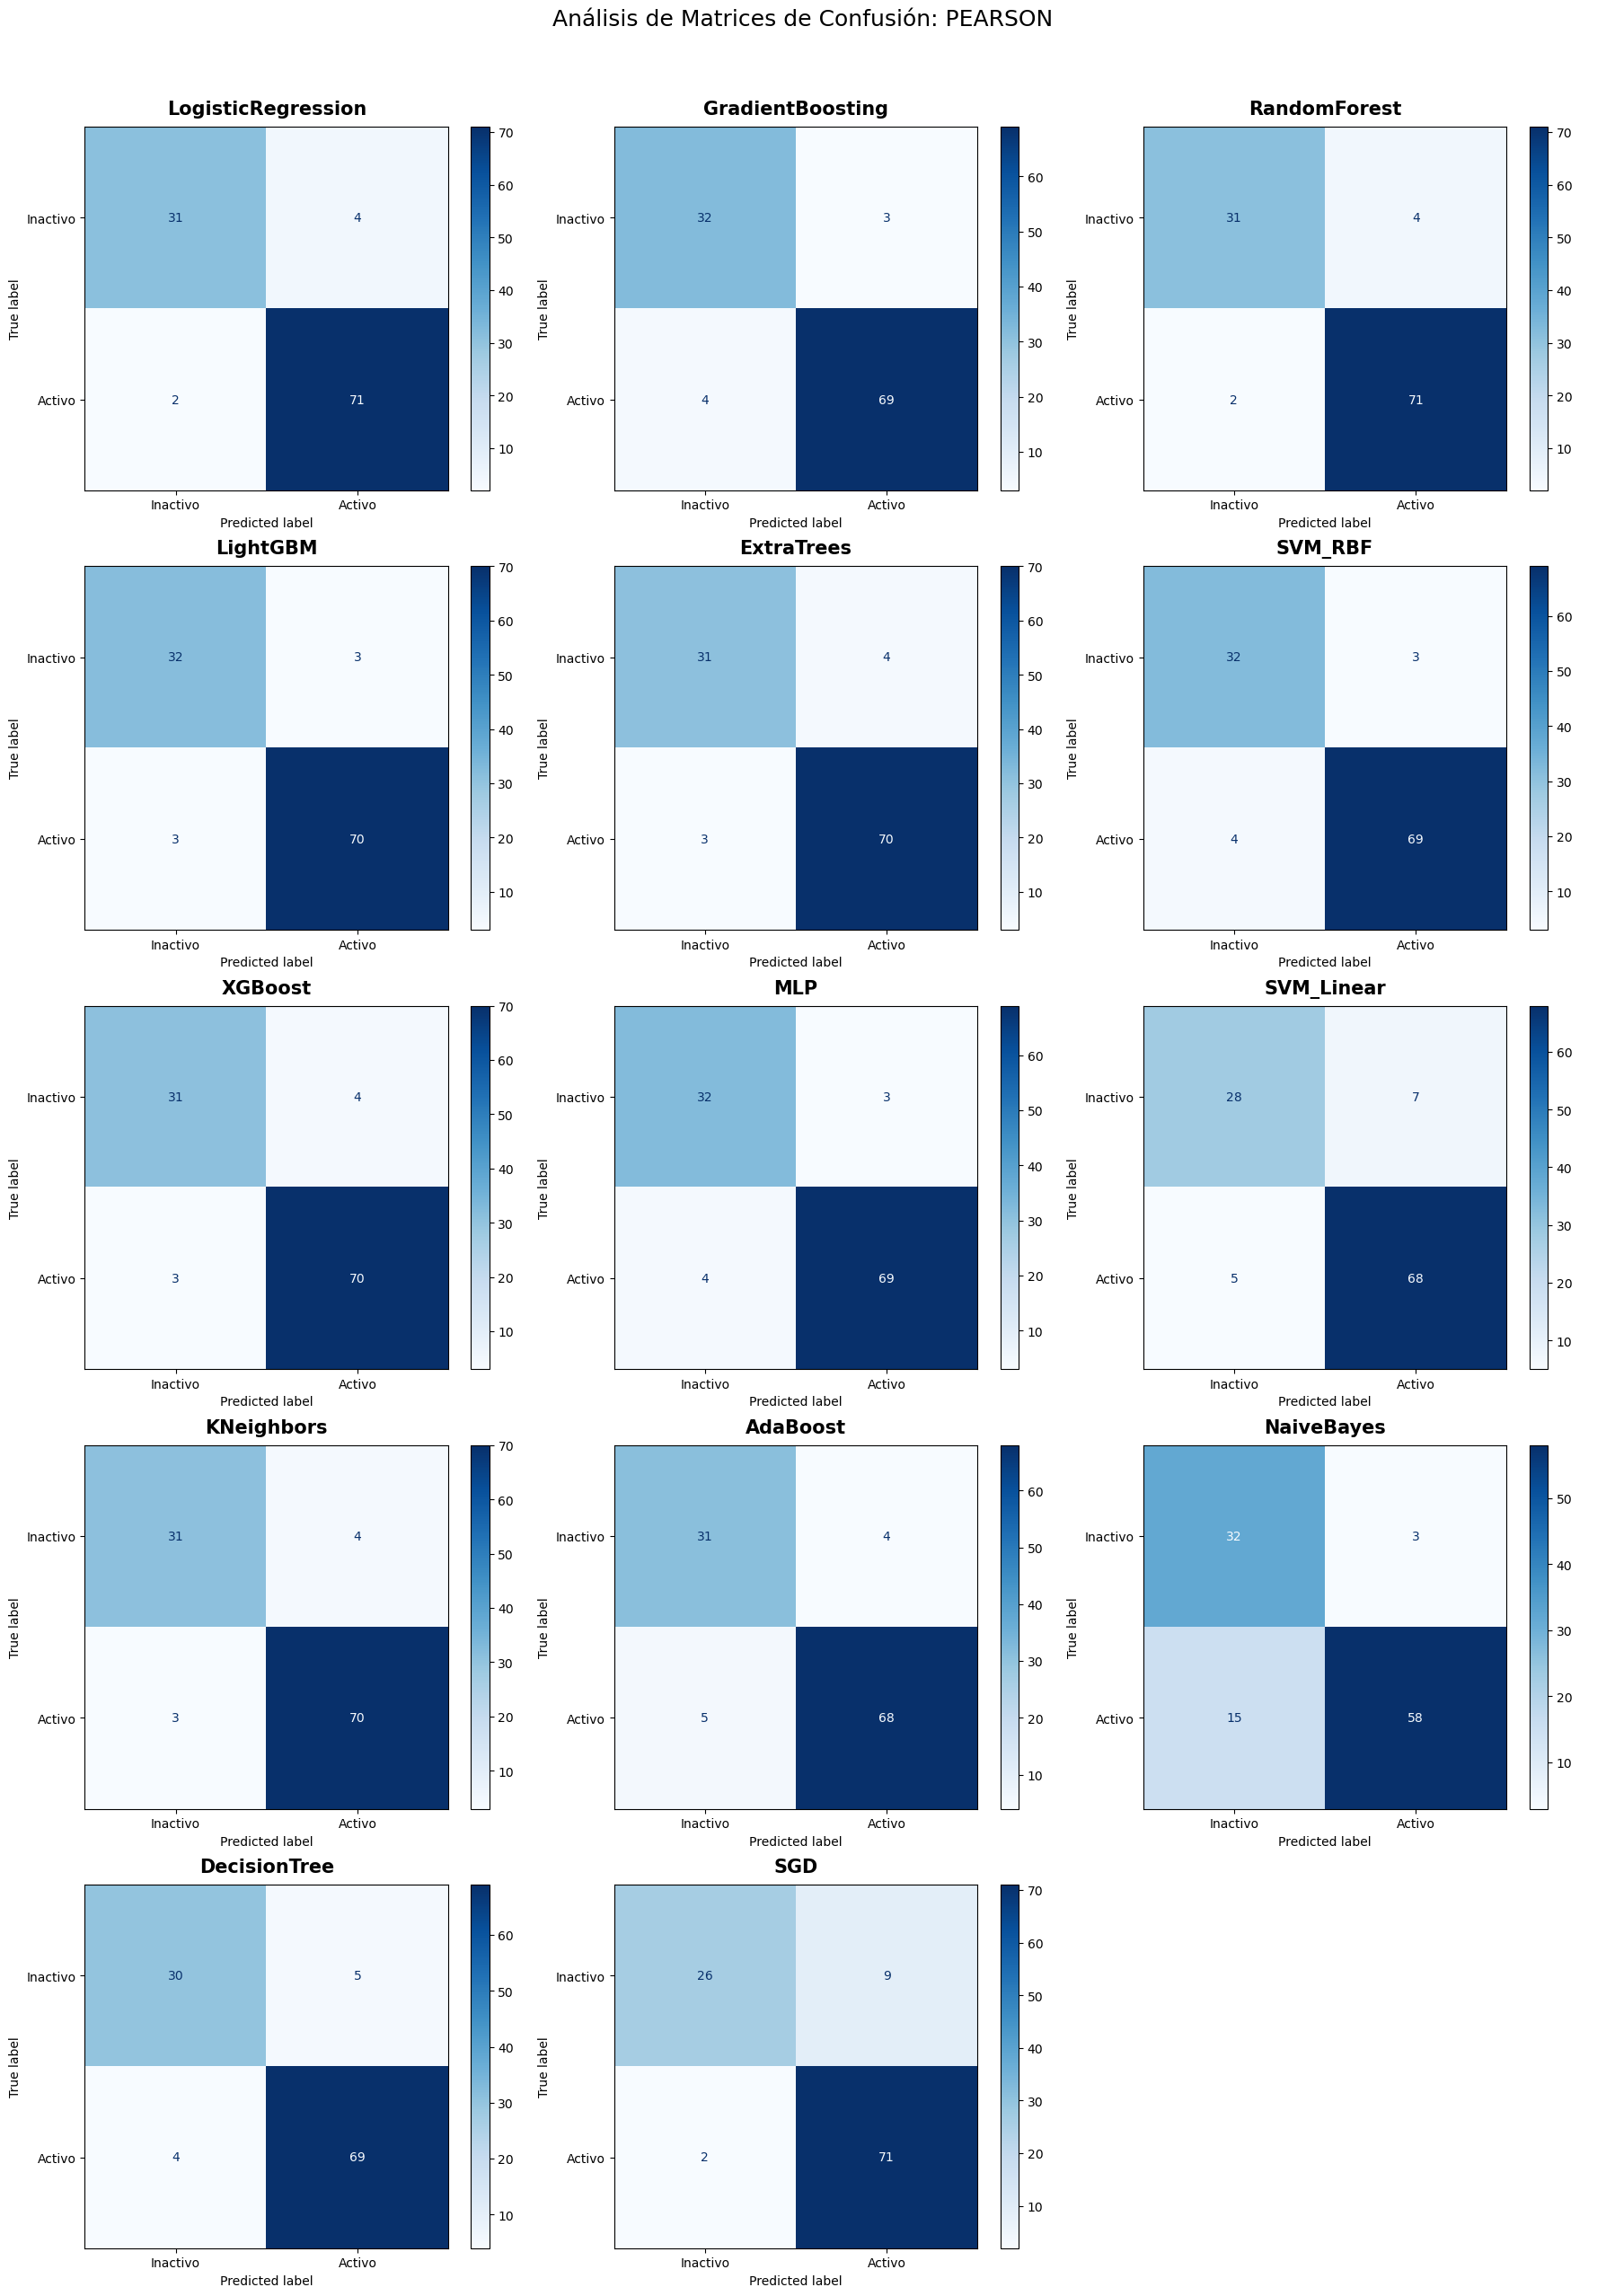

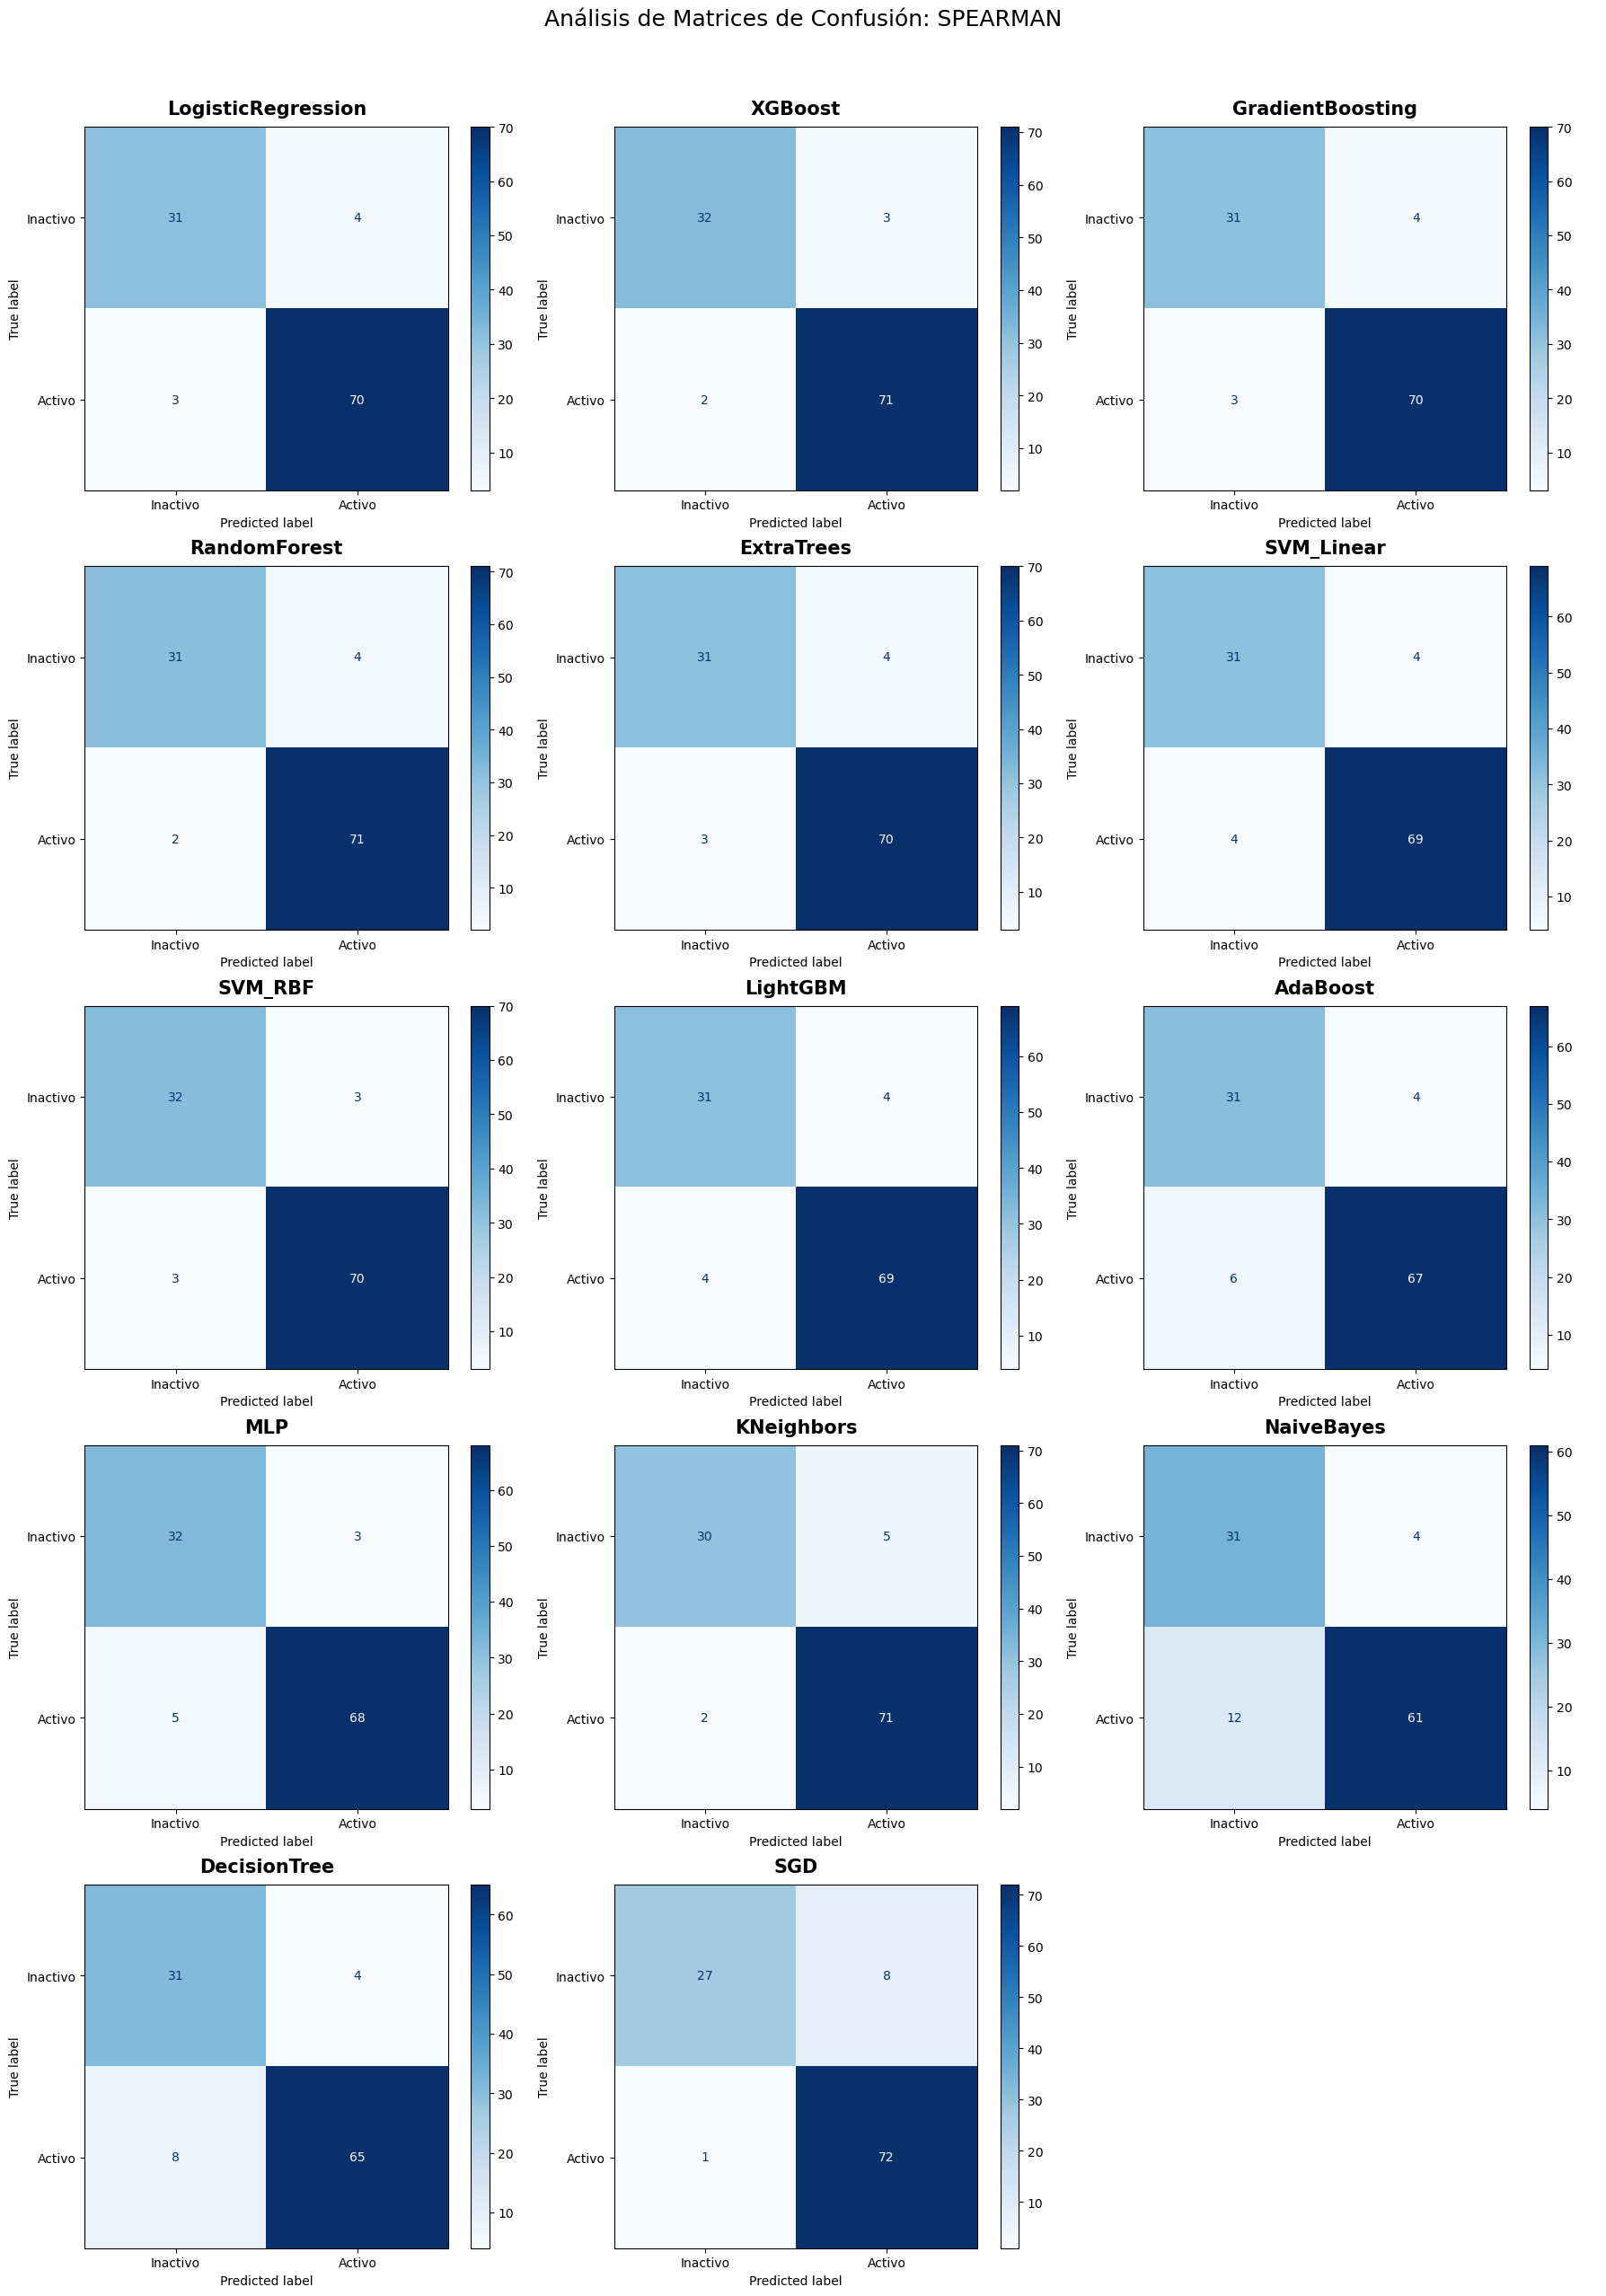

In [46]:
def plot_matrices_final(method_name, results_df, estimators_dict, feature_sets_dict):
    method_results = results_df[results_df["feature_set"].str.contains(method_name, case=False)]
    n_models = len(method_results)
    if n_models == 0: return
    cols = 3
    rows = math.ceil(n_models / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
    axes = axes.flatten()
    for i, (_, row) in enumerate(method_results.iterrows()):
        model_name = row['model']
        fs_name = row['feature_set']
        key = f"{model_name}__{fs_name}"
        est = estimators_dict[key]
        fs_cols = feature_sets_dict[fs_name]
        y_pred = est.predict(X_test_full[fs_cols])
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=["Inactivo", "Activo"])
        disp.plot(ax=axes[i], colorbar=True, cmap="Blues")
        axes[i].set_title(f"{model_name}", fontsize=15, pad=10,fontweight='bold')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f"Análisis de Matrices de Confusión: {method_name.upper()}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig(f"paso7_confusion_{method_name}_final.png", dpi=150, bbox_inches="tight")
    plt.show()
plot_matrices_final("pearson", df_results, best_estimators, feature_sets)
plot_matrices_final("spearman", df_results, best_estimators, feature_sets)

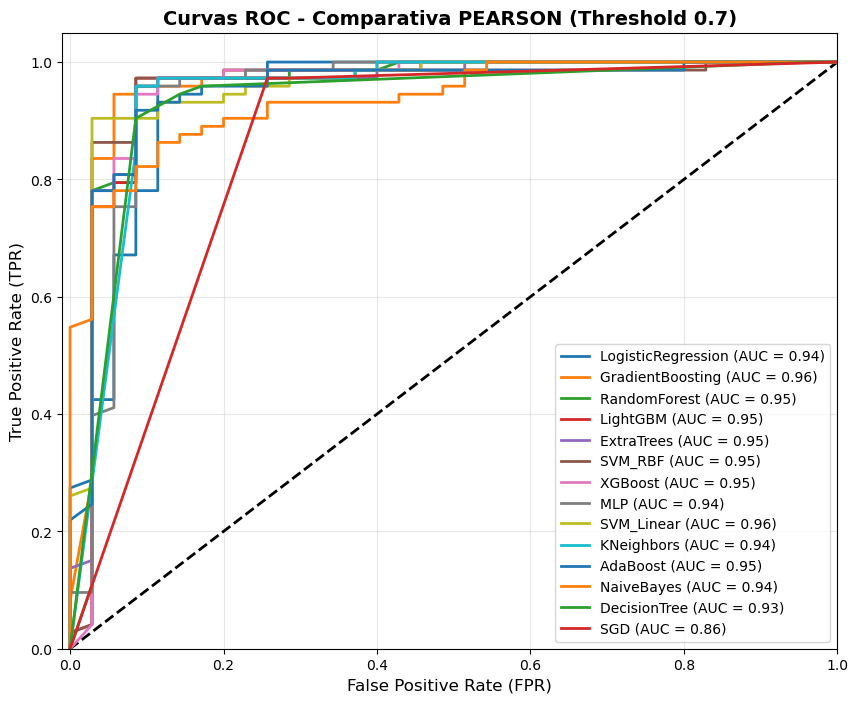

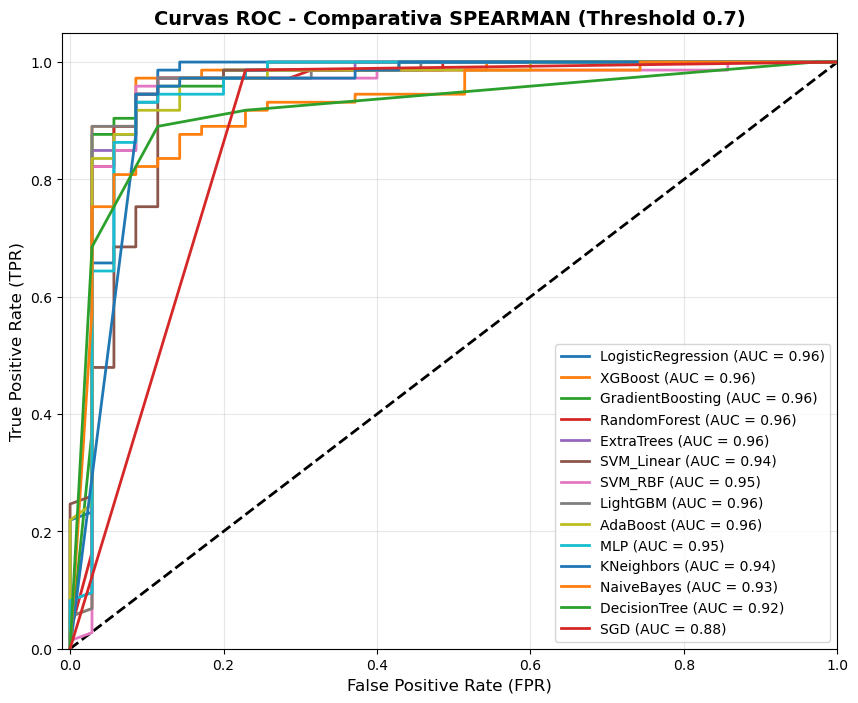

In [47]:
def plot_roc_curves_by_method(method_name, results_df, estimators_dict, feature_sets_dict):
    method_results = results_df[results_df["feature_set"].str.contains(method_name, case=False)]
    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    
    for _, row in method_results.iterrows():
        model_name = row['model']
        fs_name = row['feature_set']
        key = f"{model_name}__{fs_name}"
        est = estimators_dict[key]
        fs_cols = feature_sets_dict[fs_name]
        if hasattr(est, "predict_proba"):
            y_score = est.predict_proba(X_test_full[fs_cols])[:, 1]
        else:
            y_score = est.decision_function(X_test_full[fs_cols])
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title(f'Curvas ROC - Comparativa {method_name.upper()} (Threshold 0.7)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.savefig(f"paso7_roc_comparison_{method_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Ejecutar para Pearson y Spearman
plot_roc_curves_by_method("pearson", df_results, best_estimators, feature_sets)
plot_roc_curves_by_method("spearman", df_results, best_estimators, feature_sets)

In [48]:
pivot_auc = df_results.pivot_table(
    index="model", columns="feature_set",
    values="roc_auc_test", aggfunc="max"
)
fig, ax = plt.subplots(figsize=(14, 6))
pivot_auc.plot(kind="bar", ax=ax, edgecolor="white")
ax.axhline(0.8, color="red", linestyle="--", linewidth=1, label="0.8")
ax.set_title("ROC-AUC (Test) por Modelo y Feature Set")
ax.set_ylabel("ROC-AUC")
ax.set_xlabel("")
ax.legend(title="Feature Set", bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("paso7_comparacion_modelos.png",
            dpi=150, bbox_inches="tight")
plt.close()

In [49]:
pivot_gap = df_results.pivot_table(
    index="model", columns="feature_set",
    values="overfit_gap", aggfunc="min"
)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot_gap, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Overfit Gap (acc_train − acc_test)")
plt.tight_layout()
plt.savefig("paso7_overfit_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.close()

In [50]:
best_est = best_estimators[best_key]
best_fs  = feature_sets[best_row["feature_set"]]
y_pred   = best_est.predict(X_test_full[best_fs])
 
print(f"\n{'='*60}")
print(f"MEJOR MODELO : {best_row['model']}")
print(f"Feature set  : {best_row['feature_set']} ({int(best_row['n_features'])} descriptores)")
print(f"{'='*60}")
print(classification_report(y_test, y_pred, target_names=["Inactivo", "Activo"]))
print(f"MCC = {matthews_corrcoef(y_test, y_pred):.4f}")
try:
    y_prob = best_est.predict_proba(X_test_full[best_fs])[:, 1]
    print(f"ROC-AUC = {roc_auc_score(y_test, y_prob):.4f}")
except AttributeError:
    pass
 
pd.DataFrame(
    classification_report(y_test, y_pred,
                           target_names=["Inactivo", "Activo"],
                           output_dict=True)
).T.to_csv("paso7_report_mejor_modelo.csv")
 
print(f"\n✅ Gráficos y reportes del paso 7 guardados.")


MEJOR MODELO : LogisticRegression
Feature set  : spearman_thr0.7 (117 descriptores)
              precision    recall  f1-score   support

    Inactivo       0.91      0.89      0.90        35
      Activo       0.95      0.96      0.95        73

    accuracy                           0.94       108
   macro avg       0.93      0.92      0.93       108
weighted avg       0.93      0.94      0.93       108

MCC = 0.8511
ROC-AUC = 0.9622

✅ Gráficos y reportes del paso 7 guardados.
